### Student Information
Name: Odin Schrama

Student ID: T14201103

GitHub ID: Ootje123

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary. 
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas. 
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__. 

### Second Phase Submission 

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__. 

# Phase 1

In [2]:
# test code for environment setup
import pandas as pd
import numpy as np
import nltk
nltk.download('punkt') # download the NLTK datasets
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
import plotly as py
import math
import PAMI
import umap

import helpers.data_mining_helpers as dmh

df = pd.read_csv("Reddit-stock-sentiment.csv")
df.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Odin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didn’t say thank you.,0.000000,0.000000,0.0,[],-1.0


### Exercise 2
Familiarizing yourself with the Data


In [3]:
# Select only the columns that we want to include 
df_selected = df[["type", "post_id", "subreddit", "title", "text"]]
df_selected.head()

,type,post_id,subreddit,title,text
0,comment,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,Calls on retards
1,comment,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Stunt as in like why did they even make a big ...
2,comment,mmeevio,StockMarket,How do you feel about a sitting president maki...,Seeing lots of red in the ticker.
3,post,165kllm,stockstobuytoday,Who knows more? $VMAR,Vision Marine Technologies Inc. is rewriting t...
4,comment,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,He didn’t say thank you.


In [4]:
# Only comments and posts with the word 'money' 
word = "money"

# Filter rows that contain the word
matches = df_selected[df_selected["text"].str.contains(word, case=False, na=False)]

# Print the number of times this word appears
print(f"Number of times '{word}' was found: {len(matches)}\n")
matches.head()

Number of times 'money' was found: 36



,type,post_id,subreddit,title,text
19,comment,mmig2h2,stocks,U.S. 10-year Treasury yields rise as Trump tar...,I think we are past the numbers. Just assume f...
50,comment,h6yk0ll,stockstobuytoday,Technical Analysis Thread.,"Yup - money, money"
57,comment,mmef3im,StockMarket,How do you feel about a sitting president maki...,He didn't even pretend to put his money in a b...
72,post,1jr5ag5,stockstobuytoday,Spending first $250 tmmw on stocks,"A lot of stocks are down right now, and I'm th..."
87,comment,mm0e0a8,stocks,Rate My Portfolio - r/Stocks Quarterly Thread ...,You need to stop listening to the noise and th...


In [5]:
# Only show comments from "StockMarket"
SM_comments = df_selected[(df_selected["subreddit"] == "StockMarket") & (df_selected["type"] == "comment")]
SM_comments.head()

,type,post_id,subreddit,title,text
2,comment,mmeevio,StockMarket,How do you feel about a sitting president maki...,Seeing lots of red in the ticker.
4,comment,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,He didn’t say thank you.
18,comment,mmkcc4d,StockMarket,Trump: We Are Doing Really Well On Our Tariff ...,Trump and dump
26,comment,mmjxgi0,StockMarket,🚨China responds to Trump’s 145% tariff with an...,China will never lose a trade war. Delusional ...
32,comment,mmk4qd8,StockMarket,Data Shows US Allies—Not China—Dumping Treasuries,Sorry; I’m dumb but is this not just a USD to ...


### Exercise 3

In [6]:
# Filter the dataframe from a specific subreddit
STB_df = df_selected[df_selected['subreddit'] == "stockstobuytoday"]

# Select all 10th records and display the first 5 rows
every_10th = STB_df.iloc[::10]
every_10th.head(5) 

,type,post_id,subreddit,title,text
3,post,165kllm,stockstobuytoday,Who knows more? $VMAR,Vision Marine Technologies Inc. is rewriting t...
59,comment,gui4bru,stockstobuytoday,r/stockstobuytoday Lounge,heard chatter upto $350
112,comment,ke2q751,stockstobuytoday,Anyone been looking into OneMedNet?,"nice, good info, good post."
158,post,t2px6r,stockstobuytoday,What will happen with 2022?,Investors brace for more volatility as the wes...
186,comment,ho0pqki,stockstobuytoday,$PPSI short squeeze 43% shorted,Date|Symbol|ShortVolume|ShortExemptVolume|Tota...


### Exercise 4
Here we analyze missing values using the full dataframe (df), not just the selected columns, which were mainly used for visualization.

In [7]:
# check for missing values
missing_values= df.isnull().apply(lambda row: dmh.check_missing_values(row), axis=1)

# Preview missing value information for the first few rows
print(missing_values)
len(df)

0      (The amoung of missing records is: , 2)
1      (The amoung of missing records is: , 2)
2      (The amoung of missing records is: , 2)
3      (The amoung of missing records is: , 0)
4      (The amoung of missing records is: , 2)
                        ...                   
842    (The amoung of missing records is: , 2)
843    (The amoung of missing records is: , 2)
844    (The amoung of missing records is: , 0)
845    (The amoung of missing records is: , 2)
846    (The amoung of missing records is: , 2)
Length: 847, dtype: object


847

### Exercise 5 and 6

I have explained these questions already in the Master file, so not necessary.

### Exercise 7

Automatically set the y-axis limit in a bar chart based on the maximum value of the sampled data.We apply this to visualize the counts of comments versus posts in the wallstreetbets subreddit

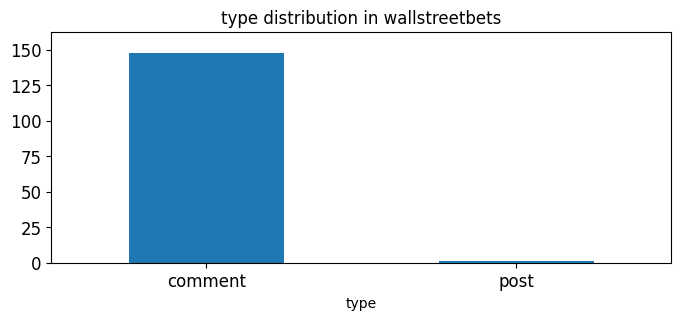

In [11]:
import matplotlib.pyplot as plt

# Filter the dataset for 'wallstreetbets'
wsb_df = df[df['subreddit'] == 'wallstreetbets']

# Get counts for the selected column
counts = wsb_df['type'].value_counts()

counts.plot(
    kind='bar',
    title= 'type distribution in wallstreetbets',
    ylim=[0, counts.max() * 1.1],
    rot=0, fontsize=12, figsize=(8,3)
)
plt.show()

### Exercise 8

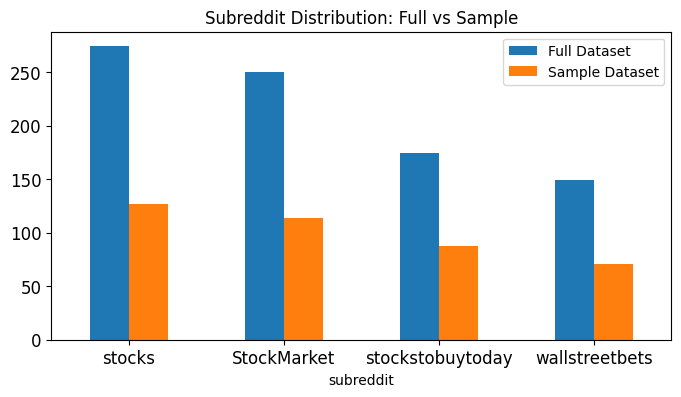

In [12]:
# Counts for full dataset and sample
full_counts = df['subreddit'].value_counts()
sample_counts = df.sample(n=400, random_state=42)['subreddit'].value_counts()

# Combine into a single DataFrame
comparison = pd.DataFrame({
    'Full Dataset': full_counts,
    'Sample Dataset': sample_counts.reindex(full_counts.index, fill_value=0)
})

# Plot side-by-side bar chart
comparison.plot(kind='bar', figsize=(8,4), rot=0, fontsize=12,
                title='Subreddit Distribution: Full vs Sample')
plt.show()


### Exercise 9
Feature creation

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
count_vect = CountVectorizer()
X_counts = count_vect.fit_transform(df['text'].astype(str))  # ensure text type

# Select the 5th record (index 4)
row = X_counts[4, :]

# Get indices of words with count exactly 1
word_indices = [i for i in row.nonzero()[1] if row[0, i] == 1]

# Map indices to words
words = count_vect.get_feature_names_out()[word_indices]

# Print results with hashtags
print(f"Indices with value 1: {word_indices}")
print("Words in the 5th record that appear exactly once:", words)


Indices with value 1: [np.int32(1846), np.int32(1169), np.int32(3349), np.int32(3844), np.int32(4333)]
Words in the 5th record that appear exactly once: ['he' 'didn' 'say' 'thank' 'you']


### Exercise 10

In [16]:
X_counts = count_vect.fit_transform(df['text'])

# Select the 5th record (index 4)
row = X_counts[4]

# Get indices of non-zero counts (words that appear in this text)
word_indices = row.nonzero()[1]

# Map indices to words in the vocabulary
words = count_vect.get_feature_names_out()[word_indices]

print("Indices with non-zero counts:", word_indices)
print("Words appearing in the 5th record:", words)

Indices with non-zero counts: [1846 1169 3349 3844 4333]
Words appearing in the 5th record: ['he' 'didn' 'say' 'thank' 'you']


### Exercise 11

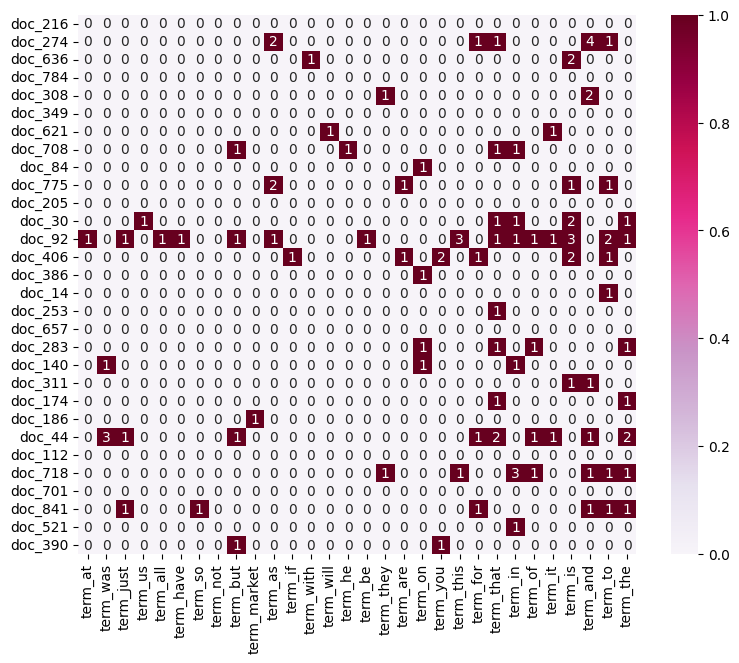

In [20]:
import seaborn as sns

count_vect = CountVectorizer()
X_counts = count_vect.fit_transform(df['text'])

# Top 30 terms
top_idx = np.argsort(np.array(X_counts.sum(axis=0)).flatten())[-30:]

# Sample 30 documents
sample_docs = np.random.choice(X_counts.shape[0], 30, replace=False)

# Create DataFrame for heatmap
df_heatmap = pd.DataFrame(
    X_counts[sample_docs][:, top_idx].toarray(),
    columns=[f"term_{w}" for w in count_vect.get_feature_names_out()[top_idx]],
    index=[f"doc_{i}" for i in sample_docs]
)

plt.figure(figsize=(9, 7))
sns.heatmap(df_heatmap, cmap="PuRd", vmin=0, vmax=1, annot=True)
plt.show()


### Exercise 12

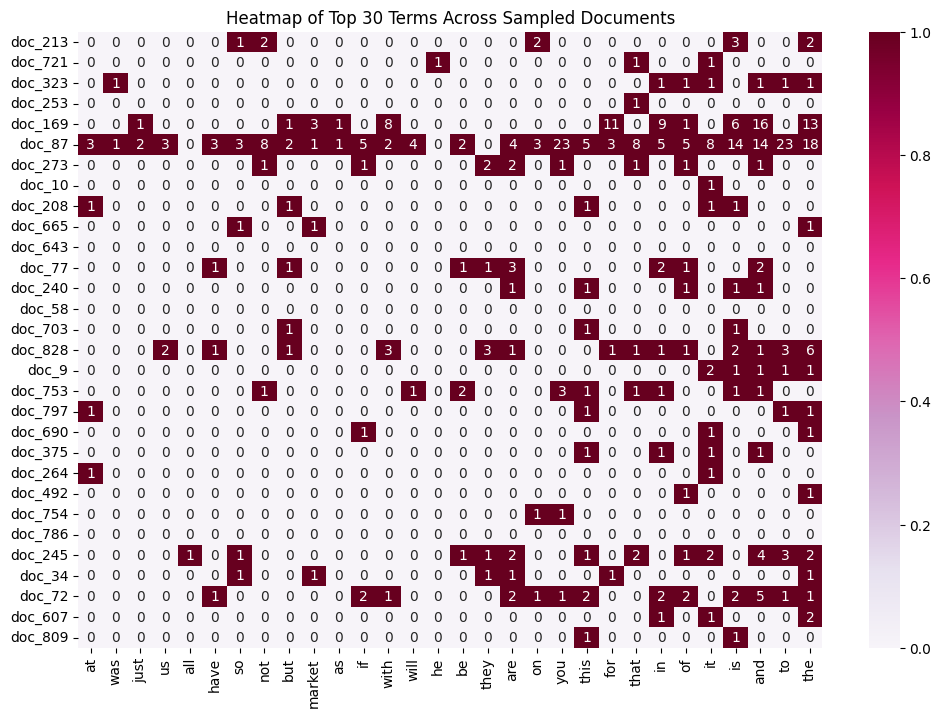

In [21]:
top_idx = np.argsort(np.array(X_counts.sum(axis=0)).flatten())[-30:]

# Sample 30 documents
sample_docs = np.random.choice(X_counts.shape[0], 30, replace=False)

# Create DataFrame for heatmap
df_heatmap = pd.DataFrame(
    X_counts[sample_docs][:, top_idx].toarray(),
    columns=[count_vect.get_feature_names_out()[i] for i in top_idx],  # actual words
    index=[f"doc_{i}" for i in sample_docs]
)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_heatmap, cmap="PuRd", vmin=0, vmax=1, annot=True)
plt.title("Heatmap of Top 30 Terms Across Sampled Documents")
plt.show()

### Exercise 13

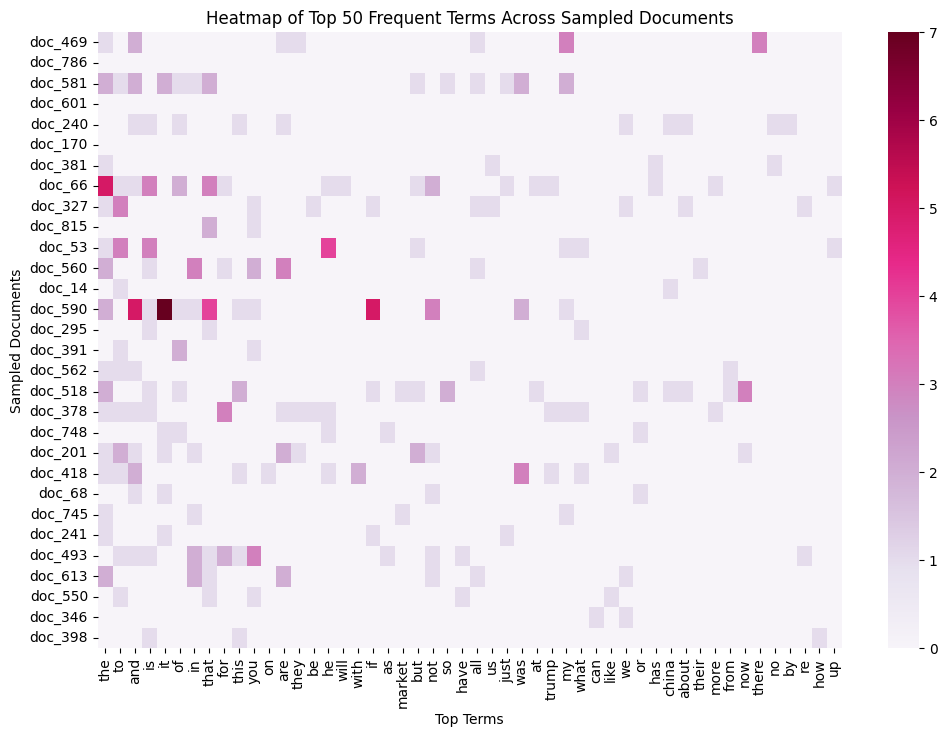

In [ ]:
count_vect = CountVectorizer()
X_counts = count_vect.fit_transform(df['text'].astype(str))
terms = count_vect.get_feature_names_out()

# Compute total term frequencies
term_frequencies = np.array(X_counts.sum(axis=0)).flatten()

# Select top 50 terms
top_terms = 50
top_idx = np.argsort(term_frequencies)[-top_terms:][::-1]

# Sample 30 random documents
sample_docs = np.random.choice(X_counts.shape[0], 30, replace=False)

# Build DataFrame for heatmap
df_heatmap = pd.DataFrame(
    X_counts[sample_docs][:, top_idx].toarray(),
    columns=[terms[i] for i in top_idx],
    index=[f"doc_{i}" for i in sample_docs]
)

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(df_heatmap, cmap="PuRd", annot=False)
plt.title("Heatmap of Top 50 Frequent Terms Across Sampled Documents")
plt.xlabel("Top Terms")
plt.ylabel("Sampled Documents")
plt.show()


### Exercise 14 

In [28]:
import plotly.express as px
import numpy as np
import pandas as pd
count_vect = CountVectorizer()
X_counts = count_vect.fit_transform(df['text'].astype(str))

# Compute term frequencies
term_frequencies = np.array(X_counts.sum(axis=0)).flatten()

top_terms = 50

# Get indices of top-N terms sorted by frequency (descending)
top_idx = np.argsort(term_frequencies)[-top_terms:][::-1]

# Map indices to actual words
terms = count_vect.get_feature_names_out()[top_idx]
freqs = term_frequencies[top_idx]

# Build dataframe for plotting
df_plot = pd.DataFrame({
    "term": terms,
    "frequency": freqs
})

# Plot interactive bar chart
fig = px.bar(
    df_plot,
    x="term",
    y="frequency",
    title=f"Top {top_terms} Term Frequencies in the Dataset",
    labels={"term": "Terms", "frequency": "Frequency"},
    text="frequency"
)

# Adjust layout for readability
fig.update_layout(
    xaxis_tickangle=-90,
    height=600,
    width=2500  # adjust width as needed for your screen
)

fig.show()


### Exercise 15

Using a logarithmic scale for term frequencies helps balance the visualization. Without it, words that appear more often will dominate the figure, making it hard to notice less common but important words. By taking the log, the extreme values are compressed, allowing words that appear less frequent to stand out more.

## Part 3: Generate meaningful new data visualizations

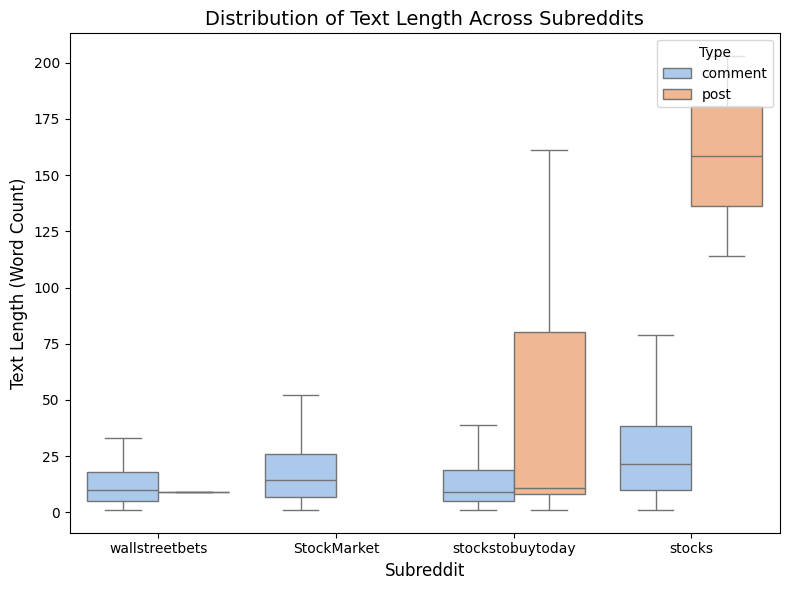

In [29]:
# Compute text length
df["text_length"] = df["text"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x="subreddit",
    y="text_length",
    hue="type",           # differentiates comment vs post
    palette="pastel",
    showfliers=False      # hide extreme outliers for clarity
)

plt.title("Distribution of Text Length Across Subreddits", fontsize=14)
plt.xlabel("Subreddit", fontsize=12)
plt.ylabel("Text Length (Word Count)", fontsize=12)
plt.legend(title="Type", loc="upper right")
plt.tight_layout()
plt.show()


This visualization compares text length across subreddits and between posts and comments. It shows that posts are generally longer than comments and that text length varies by subreddit, revealing different discussion styles and engagement levels.

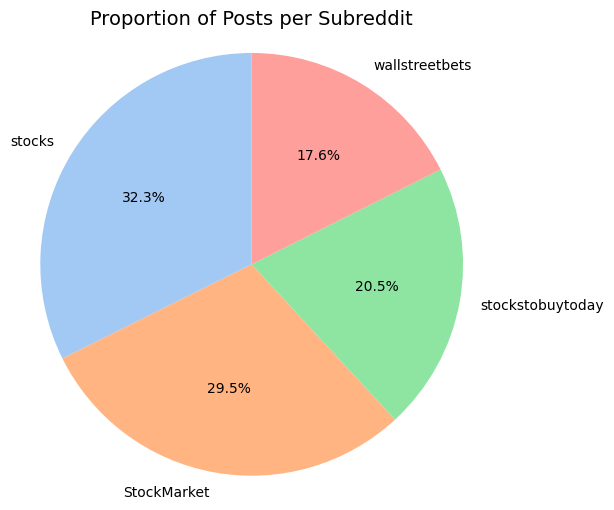

In [30]:
# Calculate subreddit proportions
sub_counts = df['subreddit'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    sub_counts,
    labels=sub_counts.index,
    autopct="%1.1f%%",     # show percentages
    startangle=90,         # start from the top
    colors=sns.color_palette("pastel")  # nice soft colors
)
plt.title("Proportion of Posts per Subreddit", fontsize=14)
plt.axis("equal")
plt.show()


This pie chart shows the proportion of posts per subreddit, illustrating how active each community is. It highlights that subreddits Stocks and StockMarket are the most active, while Wallstreetbets and Stockstobuytoday contribute fewer posts.

C:\Users\Odin\AppData\Local\Temp\ipykernel_9580\2220884801.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




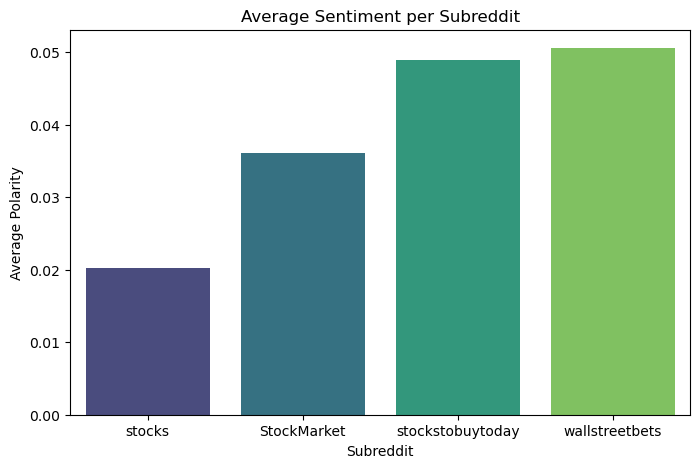

In [ ]:
sentiment_avg = df.groupby("subreddit")["polarity"].mean().sort_values()

plt.figure(figsize=(8,5))
sns.barplot(x=sentiment_avg.index, y=sentiment_avg.values, palette="viridis")
plt.title("Average Sentiment per Subreddit")
plt.xlabel("Subreddit")
plt.ylabel("Average Polarity")
plt.show()


This bar chart shows the average sentiment (polarity) per subreddit. It reveals that discussions on Wallstreetbets and Stockstobuytoday are generally more positive, while Stocks tends to have more neutral or slightly negative tones.

# Phase 2

In [ ]:
### Begin Assignment Here